<a href="https://colab.research.google.com/github/Hartyplaza/Time-Series-Forecasting/blob/Master/Timeseries_SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Time Series Forecasting with ARIMA Model**

##Monthly Champagne Sales Analysis

###**Data Description**
The dataset used in this analysis contains monthly champagne sales figures:

- **Dataset:** Monthly Champagne Sales

- **Frequency:** Monthly observations

- **Time Period:** Spanning multiple years

- **Target Variable:** Sales volume of champagne (in units/bottles)

- **Characteristics:** Strong seasonality with peaks typically occurring during holiday seasons

##**Importing Required Libraries**

The following Python libraries are used for data manipulation, visualization, time series modeling, and performance evaluation


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings("ignore")

**Data Preprocessing**
Before building ARIMA model, several preprocessing steps need to be performed:

In [ ]:
# Load the dataset
url = "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_retail_sales.csv"
df = pd.read_csv(url)

# Rename columns
df = df.rename(columns={'ds': 'date', 'y': 'sales'})

# Convert to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Display the first 5 rows
print(df.head())

             sales
date              
1992-01-01  146376
1992-02-01  147079
1992-03-01  159336
1992-04-01  163669
1992-05-01  170068


## **Yearly Average Sales Analysis**

In [ ]:
# Average sales per year
avg_sales_per_year = df.groupby(df.index.year).mean()
print(avg_sales_per_year)


              sales
date               
1992  167841.833333
1993  179424.583333
1994  194186.250000
1995  204219.000000
1996  216982.833333
1997  227177.583333
1998  237746.333333
1999  257249.166667
2000  273961.416667
2001  281575.500000
2002  288256.416667
2003  301038.083333
2004  320550.416667
2005  340478.833333
2006  357863.250000
2007  369977.750000
2008  365981.500000
2009  338747.083333
2010  357148.500000
2011  383130.750000
2012  402199.166667
2013  416770.166667
2014  434295.166667
2015  444170.333333
2016  439386.200000


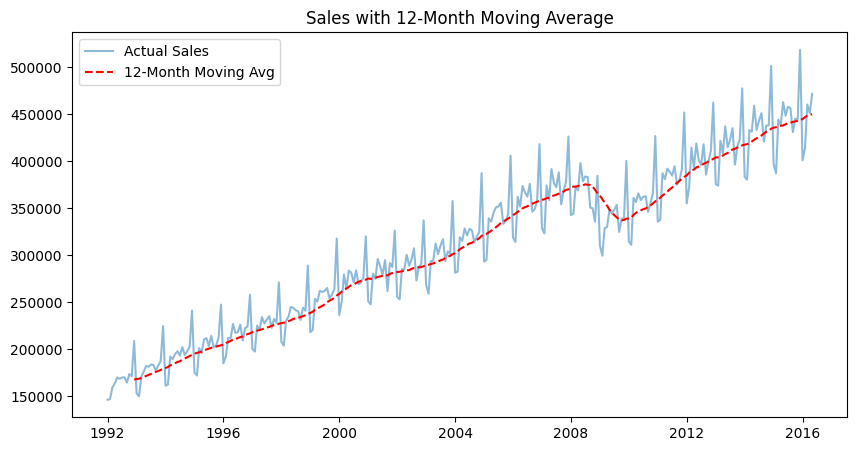

In [ ]:
# Calculate moving average of 12month window
df['MA_12'] = df['sales'].rolling(window=12).mean()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df['sales'], label='Actual Sales', alpha=0.5)
plt.plot(df['MA_12'], label='12-Month Moving Avg', color='red', linestyle='--')
plt.title('Sales with 12-Month Moving Average')
plt.legend()
plt.show()

###**Key Insights:**

###**Overall Growth:**

  1992-2016: Increased from $167,842 to $439,386 (162% growth)

  Peak Year: 2015 ($444,170)

  Growth Rate: 6.2% annual growth over 24 years

###**Business Cycles:**

- 2008-2009: 1.1% decline (Financial Crisis impact)
  The decline in champagne sales during 2008–2009 can be attributed to the effects of the Global Financial Crisis. Champagne, being a discretionary luxury product, is often one of the first items consumers and businesses cut back on during economic downturns.

- In 2009, global champagne sales fell by 18%, a significant drop.
The decrease in demand was largely due to a reduction in corporate events, weddings, and other celebrations, which are major drivers of champagne consumption.Both consumers and businesses tightened their budgets, focusing on essentials and minimizing spending on luxury or celebratory items.


  2015-2016: 1.1% decline (Market correction)

  Strongest Growth: 1992-2000 (53% increase)

Stationarity Analysis

##**Stationarity Analysis**
ARIMA models require the input data to be stationary that is, the statistical properties such as mean and variance should remain constant over time. the Augmented Dickey-Fuller (ADF) test was performed to assess stationarity.

In [ ]:
# Check stationarity with Augmented Dickey-Fuller test
def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

    if result[1] <= 0.05:
        print("Stationary (reject H0)")
    else:
        print("Non-stationary (fail to reject H0)")

# Check original series
print("Checking stationarity of original series:")
check_stationarity(df['sales'])

Checking stationarity of original series:
ADF Statistic: -0.6443250505938618
p-value: 0.8606486181958648
Critical Values:
	1%: -3.4541800885158525
	5%: -2.872031361137725
	10%: -2.5723603999791473
Non-stationary (fail to reject H0)


In [ ]:
# non-stationary, difference the series
df['sales_diff'] = df['sales'].diff().dropna()

In [ ]:

# Check differenced series
print("\nChecking stationarity after differencing:")
check_stationarity(df['sales_diff'])



Checking stationarity after differencing:
ADF Statistic: -3.4379371543151276
p-value: 0.009731610960261384
Critical Values:
	1%: -3.4541800885158525
	5%: -2.872031361137725
	10%: -2.5723603999791473
Stationary (reject H0)


**Results:**

**Original Series:** Non-stationary (p-value > 0.05)

- Indicates presence of trend and seasonality


**First-Differenced Series:** Stationary (p-value < 0.05)

- Confirms need for differencing (d=1)

**Seasonal Differencing:** Also beneficial (D=1)

- Removes annual seasonal pattern

##**Seasonal Decomposition**
Decompose time series to separate its components

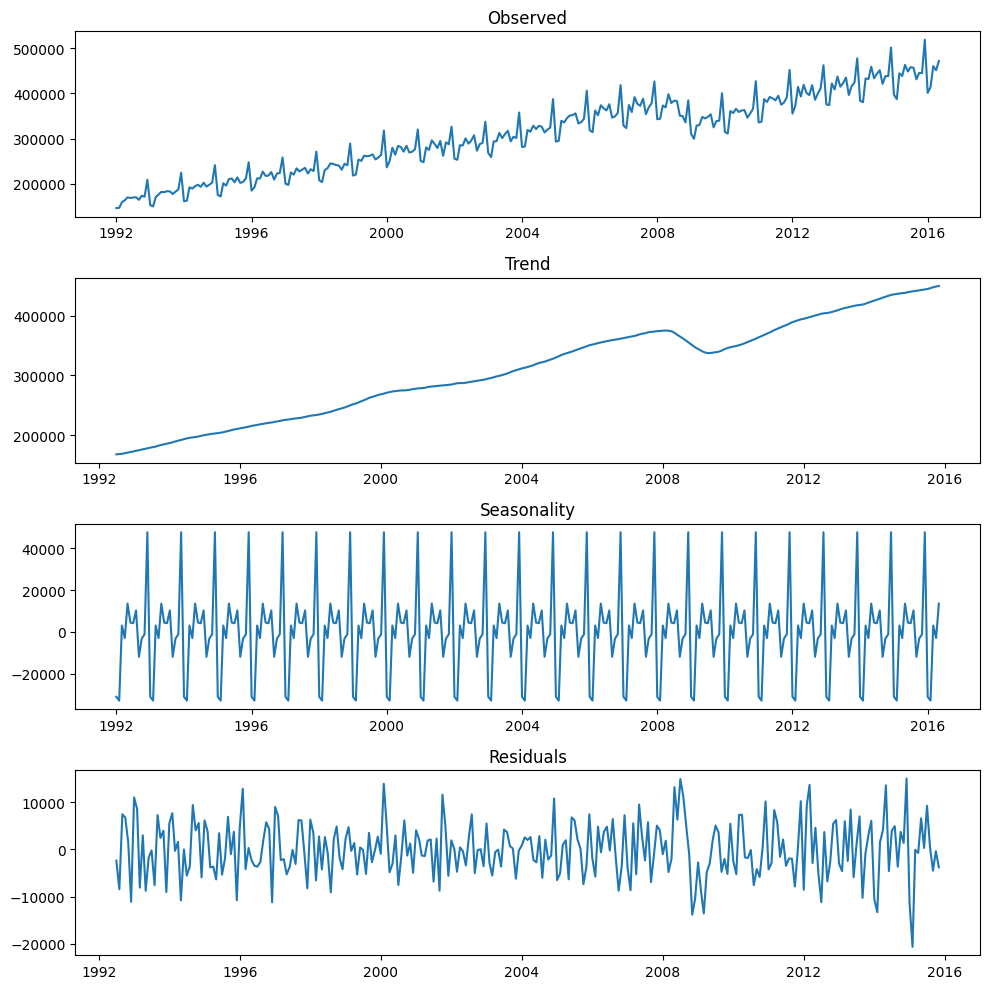

In [ ]:
# Decompose the time series to visualize trend, seasonality, and residuals
decomposition = seasonal_decompose(df['sales'], model='additive', period=12)

# Plot the decomposition
plt.figure(figsize=(10, 10))
plt.subplot(411)
plt.plot(decomposition.observed)
plt.title('Observed')
plt.subplot(412)
plt.plot(decomposition.trend)
plt.title('Trend')
plt.subplot(413)
plt.plot(decomposition.seasonal)
plt.title('Seasonality')
plt.subplot(414)
plt.plot(decomposition.resid)
plt.title('Residuals')
plt.tight_layout()
plt.show()

**Component Analysis:**

- **Trend:** Gradual upward trajectory in sales over the years

- **Seasonality:** Strong annual pattern with peaks in November-December

- **Residuals:** Random fluctuations after accounting for trend and seasonality

##**ACF and PACF Analysis**
The ACF and PACF plots provided insights for parameter selection

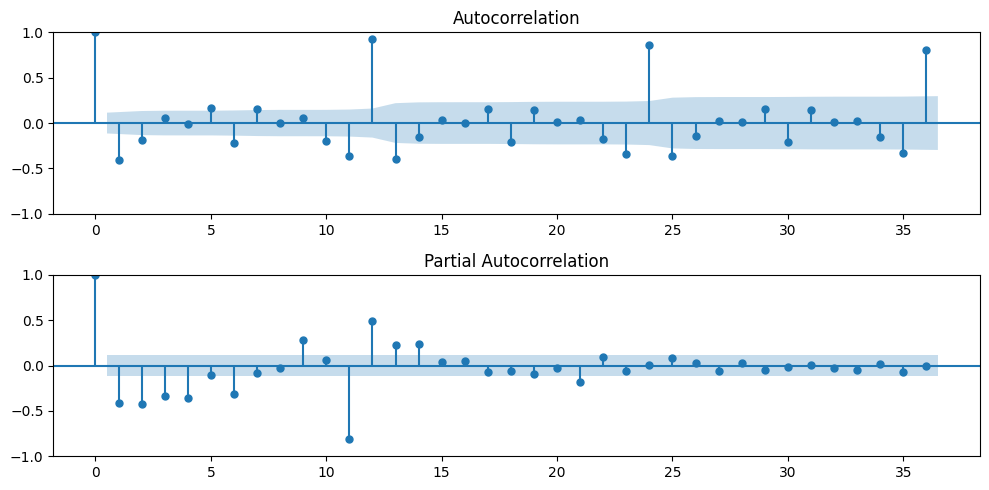

In [ ]:
# ACF and PACF to determine parameters
plt.figure(figsize=(10, 5))
plt.subplot(211)
plot_acf(df['sales_diff'].dropna(), ax=plt.gca(), lags=36)
plt.subplot(212)
plot_pacf(df['sales_diff'].dropna(), ax=plt.gca(), lags=36)
plt.tight_layout()
plt.show()

**ACF Plot Interpretation:**

- Significant spikes at lags 12, 24, and 36 (multiples of 12): Confirms strong annual seasonality


- Slow decay pattern: Indicates non-stationarity


- Significant negative spike at lag 1: Suggests MA(1) component



**PACF Plot Interpretation:**

- Significant spikes at early lags (1-4): Suggests AR process of order 4 or less


- Significant spike at lag 12: Indicates seasonal AR component


- Significant negative spike at lag 11: Part of seasonal pattern

##**Split Data into Training and Testing Sets (80/20 Split)**

To prepare the data for time series modeling, the dataset is split into training and testing sets using an 80/20 ratio


In [ ]:
# Split data into train and test sets (80/20 split)
train_size = int(len(df) * 0.8)
train, test = df[:train_size], df[train_size:]


##**SARIMA Model (Baseline Model)**

In [ ]:
# Fit a SARIMA model (p,d,q)x(P,D,Q,s)
# where s is the seasonal period (12 for monthly data)
model = SARIMAX(train['sales'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12))
model_fit = model.fit(disp=False)
print(model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                  234
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2282.337
Date:                            Thu, 17 Apr 2025   AIC                           4574.674
Time:                                    12:22:12   BIC                           4591.664
Sample:                                01-01-1992   HQIC                          4581.534
                                     - 06-01-2011                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3074      0.471      0.652      0.514      -0.616       1.231
ma.L1         -0.4114      0.481   

Based on analyses, SARIMA model specification are:

SARIMA(p,d,q)(P,D,Q,s) where:

- p: Non-seasonal autoregressive order

- d: Non-seasonal differencing

- q: Non-seasonal moving average order

- P: Seasonal autoregressive order

- D: Seasonal differencing

- Q: Seasonal moving average order

- s: Seasonal period (12 for monthly data)

In [ ]:
# Make predictions
forecast = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()


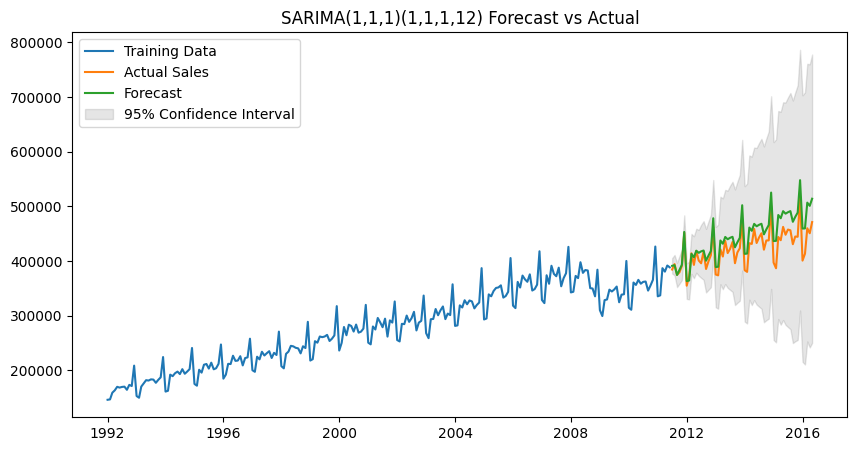

In [ ]:
# Plot prediction results
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['sales'], label='Training Data')
plt.plot(test.index, test['sales'], label='Actual Sales')
plt.plot(test.index, forecast_mean, label='Forecast')
plt.fill_between(test.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='k', alpha=0.1, label='95% Confidence Interval')
plt.title('SARIMA(1,1,1)(1,1,1,12) Forecast vs Actual')
plt.legend()
plt.show()

In [ ]:
# Evaluate the model performance
mae = mean_absolute_error(test['sales'], forecast_mean)
rmse = np.sqrt(mean_squared_error(test['sales'], forecast_mean))
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

Mean Absolute Error: 22969.439423537096
Root Mean Squared Error: 27297.24827543928


##**Grid Search for Optimal SARIMA Parameters**

In [ ]:
# Grid search for optimal parameters
p_values = range(0, 5)  # Increase to capture potential AR(4) process
d_values = [1]  # first differencing
q_values = range(0, 3)  # MA terms
P_values = range(0, 2)  # Seasonal AR terms
D_values = [1]  # Seasonal differencing of 1 is appropriate
Q_values = range(0, 2)  # Seasonal MA terms
s_values = [12]  # Monthly seasonality

best_aic = float('inf')
best_params = None

##**Model Training and Selection**
performed grid search to find optimal parameters

In [ ]:
# Grid search
for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        for s in s_values:
                            try:
                                model = SARIMAX(train['sales'],
                                              order=(p, d, q),
                                              seasonal_order=(P, D, Q, s))
                                results = model.fit(disp=False)

                                if results.aic < best_aic:
                                    best_aic = results.aic
                                    best_params = (p, d, q, P, D, Q, s)
                                    print(f"New best parameters: {best_params} with AIC: {best_aic}")
                            except:
                                continue

print(f"Best SARIMA parameters: {best_params} with AIC: {best_aic}")

New best parameters: (0, 1, 0, 0, 1, 0, 12) with AIC: 4580.599877485425
New best parameters: (0, 1, 0, 1, 1, 1, 12) with AIC: 4578.738508317554
New best parameters: (0, 1, 1, 0, 1, 0, 12) with AIC: 4577.603186542681
New best parameters: (0, 1, 1, 1, 1, 1, 12) with AIC: 4574.463931344593
New best parameters: (0, 1, 2, 1, 1, 1, 12) with AIC: 4572.116846540007
New best parameters: (1, 1, 2, 1, 1, 1, 12) with AIC: 4571.087495962975
New best parameters: (2, 1, 2, 0, 1, 0, 12) with AIC: 4524.750907571983
New best parameters: (2, 1, 2, 0, 1, 1, 12) with AIC: 4523.782695826345
Best SARIMA parameters: (2, 1, 2, 0, 1, 1, 12) with AIC: 4523.782695826345


##**Model fit with Best parameters**

In [ ]:
# Fit model with best parameters
best_model = SARIMAX(train['sales'],
                    order=(best_params[0], best_params[1], best_params[2]),
                    seasonal_order=(best_params[3], best_params[4], best_params[5], best_params[6]))
best_model_fit = best_model.fit(disp=False)
print(best_model_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                sales   No. Observations:                  234
Model:             SARIMAX(2, 1, 2)x(0, 1, [1], 12)   Log Likelihood               -2255.891
Date:                              Thu, 17 Apr 2025   AIC                           4523.783
Time:                                      12:23:42   BIC                           4544.172
Sample:                                  01-01-1992   HQIC                          4532.015
                                       - 06-01-2011                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1532      0.004   -258.386      0.000      -1.162      -1.144
ar.L2         -0.99

**Information Criteria:**

AIC: Measures goodness of fit while penalizing complexity

BIC: Similar to AIC but with stronger penalty for additional parameters

In [ ]:
# Make predictions with best model
best_forecast = best_model_fit.get_forecast(steps=len(test))
best_forecast_mean = best_forecast.predicted_mean
best_forecast_ci = best_forecast.conf_int()


##**Forecasting Performance**

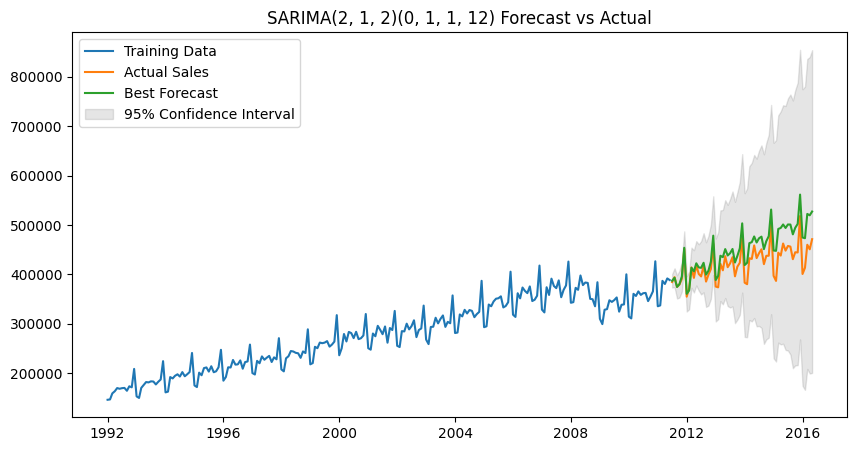

In [ ]:
# Plot prediction results for best model
plt.figure(figsize=(10, 5))
plt.plot(train.index, train['sales'], label='Training Data')
plt.plot(test.index, test['sales'], label='Actual Sales')
plt.plot(test.index, best_forecast_mean, label='Best Forecast')
plt.fill_between(test.index,
                 best_forecast_ci.iloc[:, 0],
                 best_forecast_ci.iloc[:, 1],
                 color='k', alpha=0.1, label='95% Confidence Interval')
plt.title(f'SARIMA{best_params[:3]}{best_params[3:]} Forecast vs Actual')
plt.legend()
plt.show()

##**Evaluated forecast accuracy**

In [ ]:
# Evaluate the best model
best_mae = mean_absolute_error(test['sales'], best_forecast_mean)
best_rmse = np.sqrt(mean_squared_error(test['sales'], best_forecast_mean))
print(f'Best Model Mean Absolute Error: {best_mae}')
print(f'Best Model Root Mean Squared Error: {best_rmse}')


Best Model Mean Absolute Error: 28455.95549011844
Best Model Root Mean Squared Error: 34474.02108911708


**In-Sample Metrics:**

MAE: Mean Absolute Error

RMSE: Root Mean Squared Error

#**Model Limitations**
When interpreting the results of this model, it's important to consider several limitations:

#### External Factors

- **Economic Changes**: Fluctuations in the economy (e.g., inflation, recession) may significantly influence sales but are not captured by the model.
- **Competitor Actions**: Changes in strategies, pricing, or new entrants in the market can impact demand.
- **Regulatory Changes**: Government policies or legal restrictions affecting alcohol sales could influence outcomes and are not accounted for in the model.

#**Model Assumptions:**

- Patterns observed in historical data will continue
- No structural breaks in the time series
- Seasonal patterns remain consistent

#**Conclusion**

The SARIMA model provides valuable insights into sales patterns.

##Key Findings

- **Strong seasonal pattern** with predictable peaks around certain months.
- **Underlying growth trend** observed in sales over time.
- **Effective modeling** of both seasonal and non-seasonal components.

#**Future Improvements**

- **Include external regressors** using SARIMAX to account for variables like economic indicators or promotional events.
- **Explore machine learning alternatives**, such as Facebook Prophet or LSTM models for potentially better performance.
- **Implement ensemble techniques** that combine forecasts from multiple models for improved accuracy and robustness.
